# Predicción de Abandono de Clientes en Telecomunicaciones
**Clasificación binaria — Módulo Machine Learning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 25)

## 1. ANÁLISIS Y DEPURACIÓN DE DATOS

### 1.1 Carga e inspección inicial

In [2]:
df = pd.read_csv('BBDD_ML_TAREA.csv')
print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:")
print(df.dtypes)

Dimensiones: (9200, 21)

Tipos de datos:
V1       int64
V2       int64
V3     float64
V4       int64
V5       int64
V6       int64
V7       int64
V8     float64
V9       int64
V10    float64
V11    float64
V12      int64
V13    float64
V14    float64
V15    float64
V16    float64
V17    float64
V18      int64
V19    float64
V20      int64
Y        int64
dtype: object


### 1.2 Análisis de duplicados

In [3]:
# 1) ¿Hay números de teléfono que aparecen más de una vez?
tel_counts = df['V4'].value_counts()
tel_rep = tel_counts[tel_counts > 1]
print(f"Teléfonos únicos: {df['V4'].nunique()}")
print(f"Teléfonos repetidos (aparecen >1 vez): {len(tel_rep)}")
print(f"Filas afectadas por repeticiones: {tel_rep.sum()}")

# 2) ¿Esas repeticiones son filas idénticas o clientes que cambiaron?
#    Agrupamos por V4 y miramos si todas las filas del mismo teléfono son iguales
duplicados_reales = 0
duplicados_distintos = 0

for tel, grupo in df[df['V4'].isin(tel_rep.index)].groupby('V4'):
    if grupo.drop(columns='V4').drop_duplicates().shape[0] == 1:
        duplicados_reales += len(grupo) - 1 
    else:
        duplicados_distintos += len(grupo)

print(f"\nFilas duplicadas reales (mismo tel, mismo patrón): {duplicados_reales}")
print(f"Filas con mismo tel pero distinto patrón: {duplicados_distintos}")

# 3) Verificación cruzada con duplicated() genérico
n_dup_generico = df.duplicated().sum()
print(f"\nFilas duplicadas (comprobación genérica todas las columnas): {n_dup_generico}")

# 4) Distribución de Y antes y después
print(f"\n--- Distribución de Y CON duplicados ---")
print(df['Y'].value_counts())

df_sin_dup = df.drop_duplicates()
print(f"\n--- Distribución de Y SIN duplicados ---")
print(df_sin_dup['Y'].value_counts())
print(f"\nProporción clase 1 sin duplicados: {df_sin_dup['Y'].mean()*100:.1f}%")

Teléfonos únicos: 3536
Teléfonos repetidos (aparecen >1 vez): 1921
Filas afectadas por repeticiones: 7585

Filas duplicadas reales (mismo tel, mismo patrón): 5652
Filas con mismo tel pero distinto patrón: 14

Filas duplicadas (comprobación genérica todas las columnas): 5662

--- Distribución de Y CON duplicados ---
Y
0    4600
1    4600
Name: count, dtype: int64

--- Distribución de Y SIN duplicados ---
Y
0    2832
1     706
Name: count, dtype: int64

Proporción clase 1 sin duplicados: 20.0%


In [4]:
# Eliminamos duplicados y trabajamos con los datos reales
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensiones tras eliminar duplicados: {df.shape}")
print(f"Distribución de Y: {df['Y'].value_counts().to_dict()}")

Dimensiones tras eliminar duplicados: (3538, 21)
Distribución de Y: {0: 2832, 1: 706}


In [5]:
# Eliminamos V4: identificador sin valor predictivo
df.drop(columns=['V4'], inplace=True)

### 1.3 Identificación y reclasificación de variables

In [6]:
categorical_cols = ['V1', 'V3', 'V5', 'V6']
numerical_cols   = [c for c in df.columns if c not in categorical_cols + ['Y']]

for col in categorical_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype('object')
        print(f"  {col}: convertida a categórica")

print(f"\nCategóricas ({len(categorical_cols)}): {categorical_cols}")
print(f"Numéricas   ({len(numerical_cols)}): {numerical_cols}")

# Cardinalidad de las categóricas
print("\nCardinalidad:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} valores únicos — {df[col].unique()[:5]}")

  V1: convertida a categórica
  V3: convertida a categórica
  V5: convertida a categórica
  V6: convertida a categórica

Categóricas (4): ['V1', 'V3', 'V5', 'V6']
Numéricas   (15): ['V2', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20']

Cardinalidad:
  V1: 51 valores únicos — [43 7 31 17 45]
  V3: 3 valores únicos — [415.0 510.0 408.0 nan]
  V5: 2 valores únicos — [0 1]
  V6: 2 valores únicos — [0 1]


### 1.4 Análisis descriptivo

            V2       V7       V8       V9      V10      V11      V12      V13  \
count  3538.00  3538.00  3538.00  3538.00  3525.00  3538.00  3538.00  3538.00   
mean    100.68     7.59   181.80   100.23    30.93   200.77   100.58    17.07   
std      39.70    13.45    55.50    19.78     9.43    51.03    19.62     4.34   
min       1.00     0.00     0.00     0.00     0.00    22.30    12.00     1.90   
25%      73.00     0.00   144.43    88.00    24.57   165.90    88.00    14.10   
50%     100.00     0.00   181.10   100.00    30.82   202.00   100.00    17.17   
75%     126.00    15.00   218.68   114.00    37.21   235.30   114.00    20.00   
max     243.00    52.00   351.50   160.00    59.76   363.70   170.00    30.91   

           V14      V15      V16      V17      V18      V19      V20  
count  3512.00  3510.00  3538.00  3538.00  3538.00  3522.00  3538.00  
mean    200.78    99.67     9.04    10.26     4.44     2.77     1.60  
std      50.59    20.08     2.28     2.75     2.51     0.

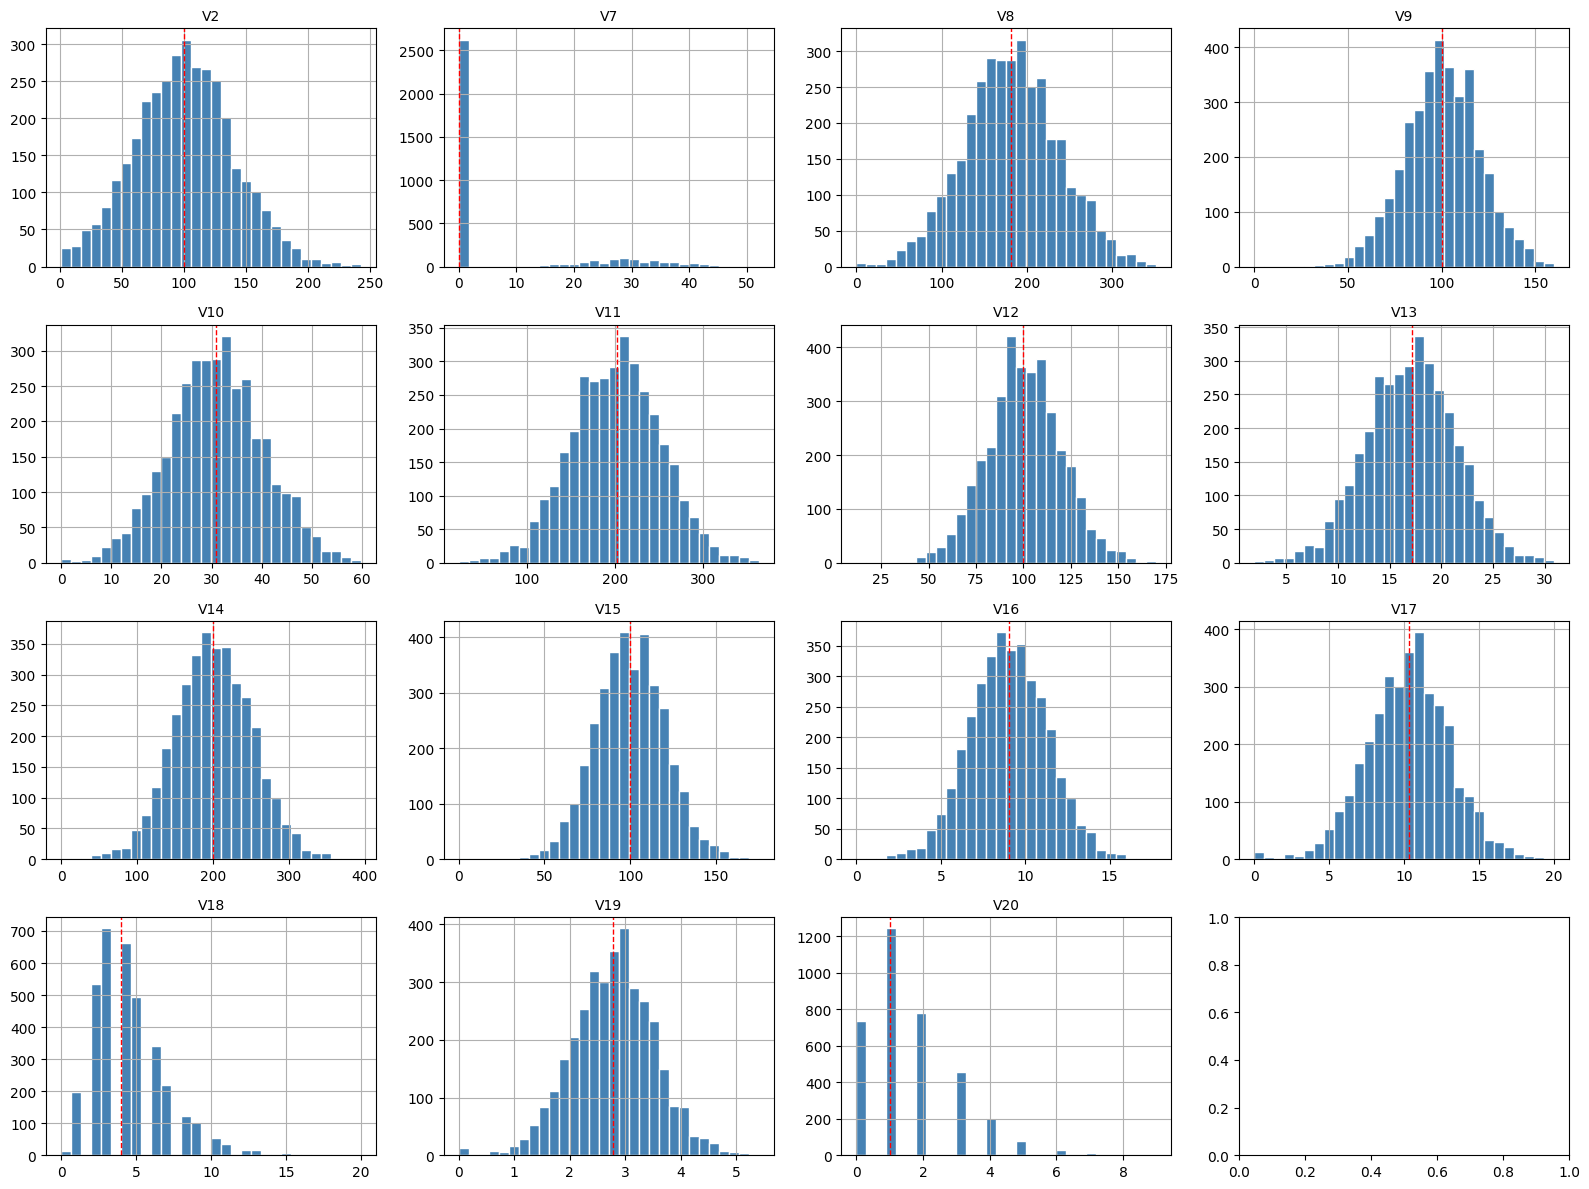

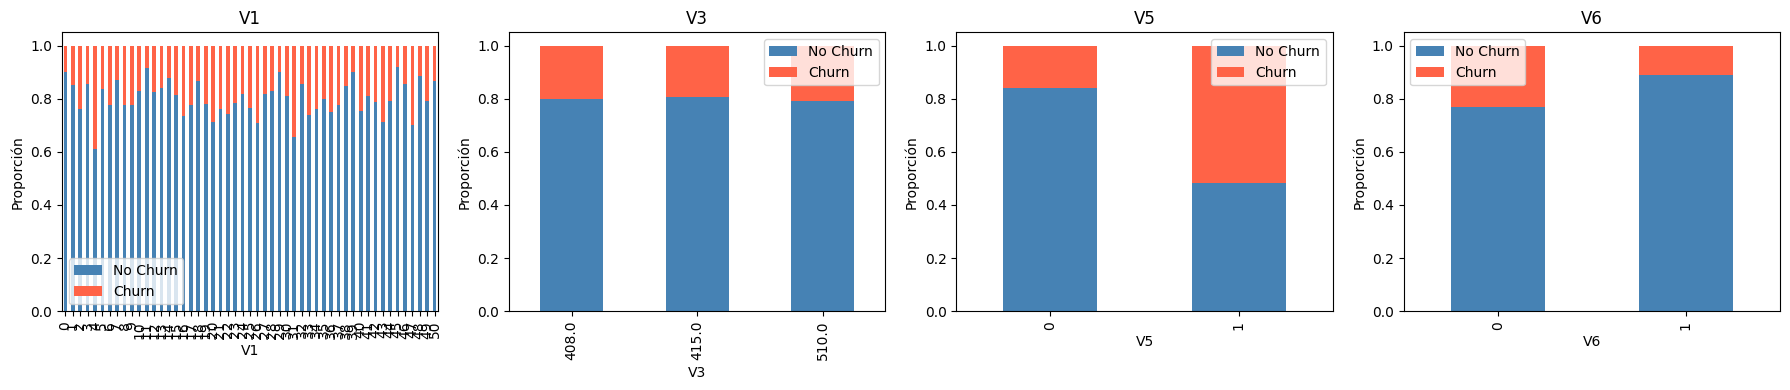

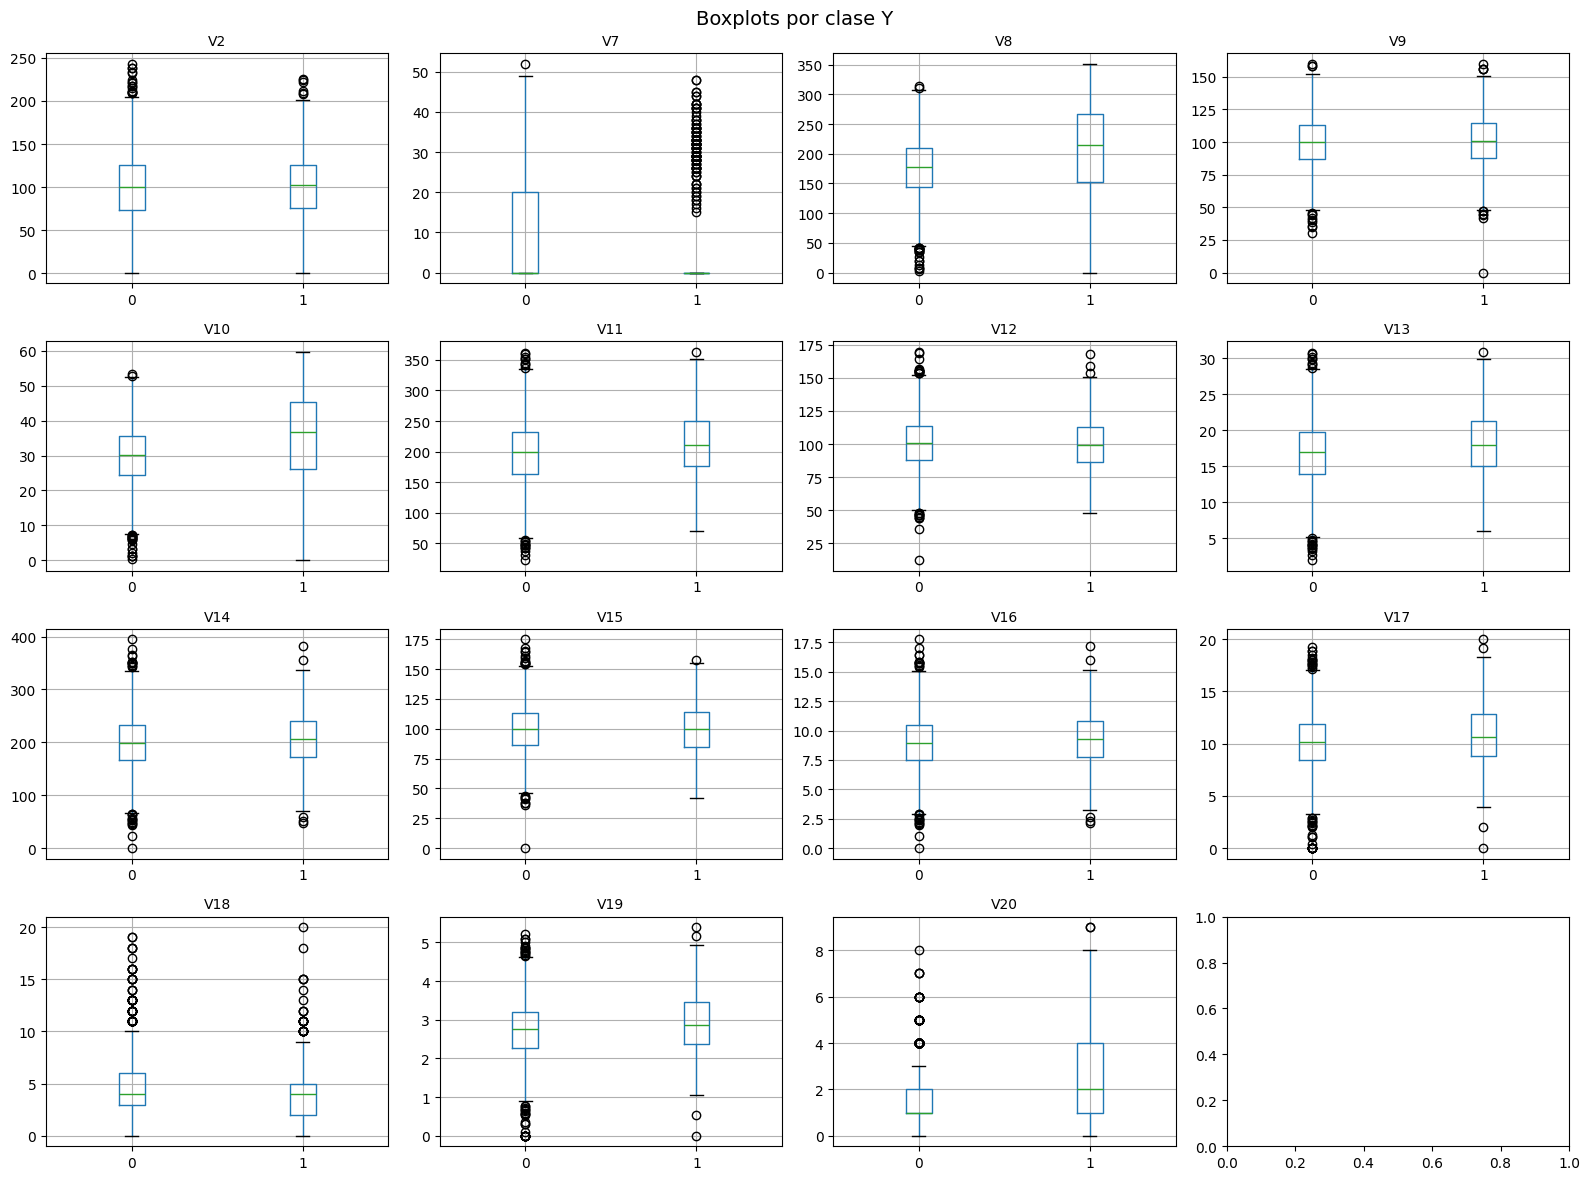

In [7]:
# Descriptivos numéricos
print(df[numerical_cols].describe().round(2))

# Histogramas de todas las numéricas
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 4, i % 4]
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.axvline(df[col].median(), color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('histogramas_numericas.png', dpi=150)
plt.show()

# Barras de las categóricas cruzadas con Y
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, col in enumerate(categorical_cols):
    pd.crosstab(df[col], df['Y'], normalize='index').plot(
        kind='bar', stacked=True, ax=axes[i], color=['steelblue','tomato'])
    axes[i].set_title(col)
    axes[i].set_ylabel('Proporción')
    axes[i].legend(['No Churn','Churn'])
plt.tight_layout()
plt.savefig('barras_categoricas.png', dpi=150)
plt.show()

# Boxplots de numéricas separadas por Y
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 4, i % 4]
    df.boxplot(column=col, by='Y', ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Boxplots por clase Y', fontsize=14)
plt.tight_layout()
plt.savefig('boxplots_por_clase.png', dpi=150)
plt.show()

### 1.5 Análisis de valores perdidos

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df)) * 100

print("--- Valores nulos ---")
for col in missing.index:
    print(f"  {col}: {missing[col]} ({missing_pct[col]:.2f}%)")
print(f"\nTodas las variables con nulos están por debajo del 2%.")
print("Se imputan con mediana (numéricas) y moda (categóricas).")

--- Valores nulos ---
  V3: 35 (0.99%)
  V10: 13 (0.37%)
  V14: 26 (0.73%)
  V15: 28 (0.79%)
  V19: 16 (0.45%)

Todas las variables con nulos están por debajo del 2%.
Se imputan con mediana (numéricas) y moda (categóricas).


In [9]:
# Imputación
# Numéricas: mediana (robusta frente a outliers y distribuciones asimétricas)
imputer_num = SimpleImputer(strategy='median')
df[numerical_cols] = imputer_num.fit_transform(df[numerical_cols])

# Categóricas: moda (la media de códigos de área no tiene sentido)
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])

print(f"Nulos restantes: {df.isnull().sum().sum()}")

Nulos restantes: 0


### 1.6 Análisis de valores atípicos

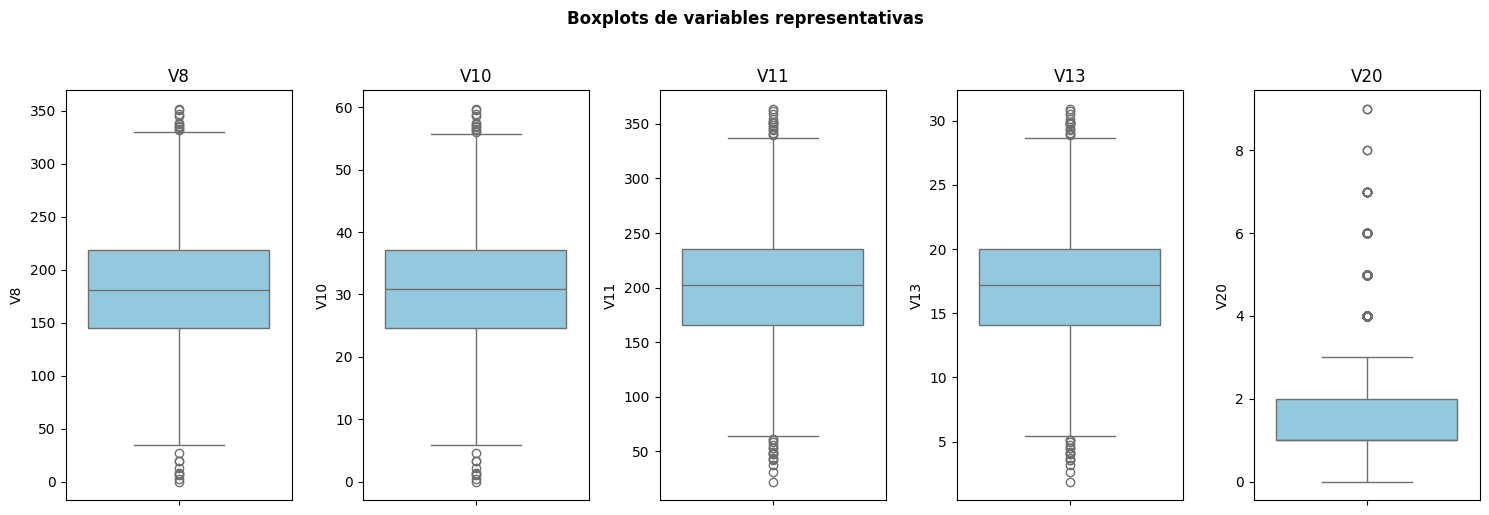

In [10]:
outlier_cols = ['V8', 'V10', 'V11', 'V13', 'V20']

plt.figure(figsize=(15, 5))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col}')
plt.suptitle('Boxplots de variables representativas', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Detección cuantitativa mediante IQR × 1.5
print("Detección estadística (IQR × 1.5):")
for col in numerical_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        print(f"  {col}: {n_out} outliers ({n_out/len(df)*100:.2f}%)")

Detección estadística (IQR × 1.5):
  V2: 22 outliers (0.62%)
  V7: 150 outliers (4.24%)
  V8: 19 outliers (0.54%)
  V9: 27 outliers (0.76%)
  V10: 20 outliers (0.57%)
  V11: 31 outliers (0.88%)
  V12: 29 outliers (0.82%)
  V13: 31 outliers (0.88%)
  V14: 32 outliers (0.90%)
  V15: 24 outliers (0.68%)
  V16: 31 outliers (0.88%)
  V17: 49 outliers (1.38%)
  V18: 93 outliers (2.63%)
  V19: 49 outliers (1.38%)
  V20: 326 outliers (9.21%)


### 1.7 Relaciones entre variables y la target

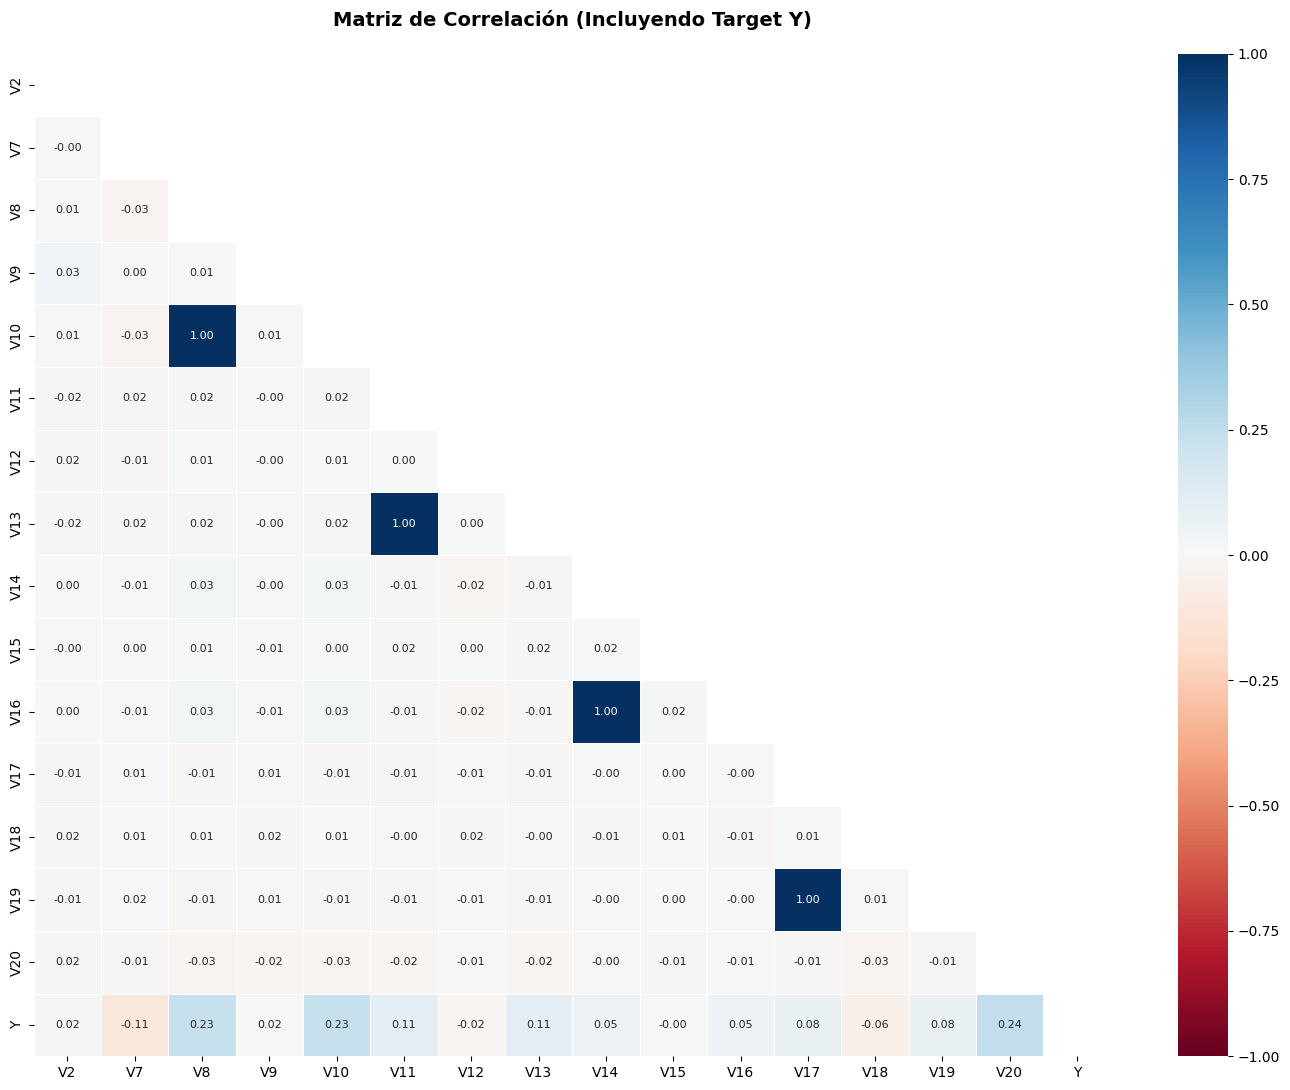

In [12]:
# Correlación de Pearson para numéricas
df_temp = df.copy()
df_temp['Y'] = df_temp['Y'].astype(float)
cols_corr = numerical_cols + ['Y']
matriz_corr = df_temp[cols_corr].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu", vmin=-1, vmax=1, center=0,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Matriz de Correlación (Incluyendo Target Y)",
          fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

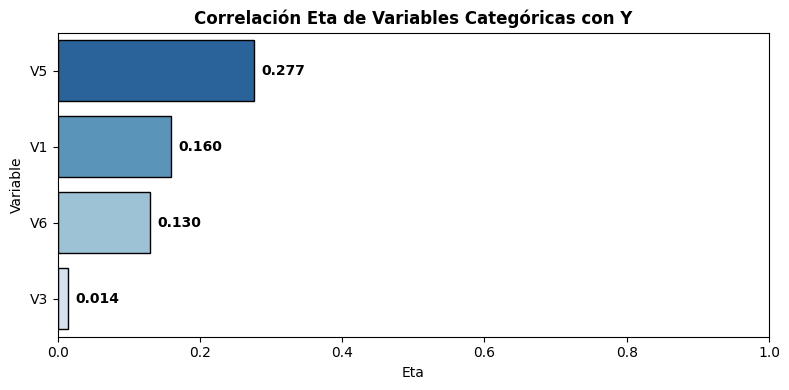

In [13]:
# Razón de correlación (eta) para categóricas vs Y
def eta_correlation(categorical_array, continuous_array):
    cats = pd.Categorical(categorical_array)
    categories = cats.categories
    if len(categories) <= 1:
        return 0.0
    overall_mean = np.mean(continuous_array)
    sum_sq_total = np.sum((continuous_array - overall_mean) ** 2)
    sum_sq_between = 0
    for cat in categories:
        mask = cats == cat
        cat_mean = np.mean(continuous_array[mask])
        sum_sq_between += np.sum(mask) * (cat_mean - overall_mean) ** 2
    return np.sqrt(sum_sq_between / sum_sq_total) if sum_sq_total > 0 else 0.0

cat_cols = ["V1", "V3", "V5", "V6"]
correlaciones = []
for col in cat_cols:
    val = eta_correlation(df[col], df["Y"])
    correlaciones.append({"Variable": col, "Eta": val})

df_corr = pd.DataFrame(correlaciones).sort_values(by="Eta", ascending=False)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x="Eta", y="Variable", data=df_corr, palette="Blues_r", edgecolor="black")
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height()/2),
                ha="left", va="center", xytext=(5, 0), textcoords="offset points",
                fontsize=10, fontweight="bold")
plt.xlim(0, 1)
plt.title("Correlación Eta de Variables Categóricas con Y", fontweight="bold")
plt.tight_layout()
plt.show()

### 1.8 Feature Engineering

In [14]:
df_fe = df.copy()

# Consumo agregado por franjas horarias
df_fe['Total_Minutos']  = df_fe['V8']  + df_fe['V11'] + df_fe['V14'] + df_fe['V17']
df_fe['Total_Llamadas'] = df_fe['V9']  + df_fe['V12'] + df_fe['V15'] + df_fe['V18']
df_fe['Total_Coste']    = df_fe['V10'] + df_fe['V13'] + df_fe['V16'] + df_fe['V19']

# Coste por minuto: percepción de valor del plan
df_fe['Coste_Por_Minuto'] = df_fe['Total_Coste'] / (df_fe['Total_Minutos'] + 1e-6)

# Ratio soporte/antigüedad: insatisfacción temprana
df_fe['Ratio_Soporte_Antiguedad'] = df_fe['V20'] / (df_fe['V2'] + 1)

nuevas = ['Total_Minutos','Total_Llamadas','Total_Coste',
          'Coste_Por_Minuto','Ratio_Soporte_Antiguedad']
print("Correlación con Y de las nuevas variables:")
print(df_fe[nuevas].corrwith(df_fe['Y']).abs().sort_values(ascending=False).round(4))

Correlación con Y de las nuevas variables:
Total_Coste                 0.2645
Total_Minutos               0.2310
Coste_Por_Minuto            0.1104
Ratio_Soporte_Antiguedad    0.0836
Total_Llamadas              0.0073
dtype: float64


In [15]:
# Correlación entre las variables originales y sus agregados
# Esto justifica eliminar V8-V19: son componentes aditivos exactos de los agregados
print("Correlación de cada variable original con su agregado:\n")

pares = {
    'Minutos':  (['V8','V11','V14','V17'], 'Total_Minutos'),
    'Llamadas': (['V9','V12','V15','V18'], 'Total_Llamadas'),
    'Coste':    (['V10','V13','V16','V19'], 'Total_Coste'),
}

for grupo, (cols, agregado) in pares.items():
    print(f"  {grupo} ({agregado}):")
    for col in cols:
        r = df_fe[col].corr(df_fe[agregado])
        print(f"    {col} vs {agregado}: r = {r:.4f}")
    print()

Correlación de cada variable original con su agregado:

  Minutos (Total_Minutos):
    V8 vs Total_Minutos: r = 0.6317
    V11 vs Total_Minutos: r = 0.5608
    V14 vs Total_Minutos: r = 0.5592
    V17 vs Total_Minutos: r = 0.0132

  Llamadas (Total_Llamadas):
    V9 vs Total_Llamadas: r = 0.5722
    V12 vs Total_Llamadas: r = 0.5725
    V15 vs Total_Llamadas: r = 0.5799
    V18 vs Total_Llamadas: r = 0.1002

  Coste (Total_Coste):
    V10 vs Total_Coste: r = 0.8893
    V13 vs Total_Coste: r = 0.4174
    V16 vs Total_Coste: r = 0.2311
    V19 vs Total_Coste: r = 0.0520



In [16]:
# Eliminamos las variables originales que ya están recogidas en los agregados
# evita multicolinealidad perfecta
cols_drop = ['V8','V9','V10','V11','V12','V13','V14','V15','V16','V17','V18','V19']
df_fe.drop(columns=cols_drop, inplace=True)

print(f"\nVariables eliminadas (contenidas en los agregados): {cols_drop}")
print(f"Dimensiones tras feature engineering: {df_fe.shape}")


Variables eliminadas (contenidas en los agregados): ['V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19']
Dimensiones tras feature engineering: (3538, 13)


### 1.9 Preprocesamiento final

In [17]:
# One-Hot Encoding para categóricas nominales
# drop_first=True evita la trampa de la variable dummy (multicolinealidad perfecta)
df_fe = pd.get_dummies(df_fe, columns=['V1', 'V3'],
                       prefix=['Estado', 'Area'], drop_first=True)
df_fe['V5'] = df_fe['V5'].astype(int)
df_fe['V6'] = df_fe['V6'].astype(int)

print(f"Dimensiones finales: {df_fe.shape}")

Dimensiones finales: (3538, 63)


In [18]:
X = df_fe.drop(columns=['Y'])
y = df_fe['Y']

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | % Churn: {y_train.mean()*100:.1f}%")
print(f"Test:  {X_test.shape}  | % Churn: {y_test.mean()*100:.1f}%")

# --- Definición de conjuntos de variables ---
# V1 genera 50 dummies y V3 otras 2. Identificamos las columnas geográficas.
cols_estado = [c for c in X_train.columns if c.startswith("Estado_")]
cols_area   = [c for c in X_train.columns if c.startswith("Area_")]
cols_geo    = cols_estado + cols_area
cols_reducido = [c for c in X_train.columns if c not in cols_geo]

print(f"\nConjunto completo: {X_train.shape[1]} variables")
print(f"Conjunto reducido (sin V1 ni V3): {len(cols_reducido)} variables")
print(f"Variables reducidas: {cols_reducido}")

# --- Estandarización: fit SOLO sobre train ---
# Conjunto COMPLETO (para RF y Stacking)
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_test_scaled  = scaler_full.transform(X_test)

# Conjunto REDUCIDO (para SVM y Bagging)
scaler_red = StandardScaler()
X_train_svm = scaler_red.fit_transform(X_train[cols_reducido])
X_test_svm  = scaler_red.transform(X_test[cols_reducido])

print(f"\nX_train_scaled (completo): {X_train_scaled.shape}")
print(f"X_train_svm (reducido):    {X_train_svm.shape}")


Train: (2830, 62) | % Churn: 20.0%
Test:  (708, 62)  | % Churn: 19.9%

Conjunto completo: 62 variables
Conjunto reducido (sin V1 ni V3): 10 variables
Variables reducidas: ['V2', 'V5', 'V6', 'V7', 'V20', 'Total_Minutos', 'Total_Llamadas', 'Total_Coste', 'Coste_Por_Minuto', 'Ratio_Soporte_Antiguedad']

X_train_scaled (completo): (2830, 62)
X_train_svm (reducido):    (2830, 10)


In [19]:
# Comparación empírica: ¿el SVM funciona mejor con o sin las variables geográficas?
# Las 50 dummies de V1 (estado/región) y 2 de V3 (código de área) representan el 84%
# de las variables del dataset pero apenas aportan señal predictiva (eta de V3 con Y = 0.014).
# El kernel RBF calcula distancias euclídeas: 50 variables binarias dispersas diluyen
# la señal de las 10 variables realmente informativas.

svm_test = SVC(kernel="rbf", class_weight="balanced", random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_completo = cross_val_score(svm_test, X_train_scaled, y_train,
                                cv=skf, scoring="roc_auc").mean()
auc_reducido = cross_val_score(svm_test, X_train_svm, y_train,
                                cv=skf, scoring="roc_auc").mean()

print(f"AUC completo (62 vars):  {auc_completo:.4f}")
print(f"AUC reducido (10 vars):  {auc_reducido:.4f}")
print(f"Diferencia:              {auc_reducido - auc_completo:+.4f}")

AUC completo (62 vars):  0.8573
AUC reducido (10 vars):  0.9074
Diferencia:              +0.0500


## 2. MODELADO CON SVM

### 2.1 Búsqueda de hiperparámetros — Fase 1 (exploración amplia)

In [20]:
# FASE 1: Grid amplio de exploración (sobre el conjunto REDUCIDO de 10 variables)
param_grid_fase1 = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10, 100],
     'gamma': ['scale', 0.001, 0.01, 0.1]}
]

svm = SVC(class_weight='balanced', probability=False, random_state=42)

grid_fase1 = GridSearchCV(
    svm, param_grid_fase1, cv=3,
    scoring={'AUC': 'roc_auc', 'Accuracy': 'accuracy'},
    refit='AUC', verbose=1, n_jobs=-1
)
grid_fase1.fit(X_train_svm, y_train)

print(f"\nMejores parámetros (Fase 1): {grid_fase1.best_params_}")
print(f"AUC validación (Fase 1):     {grid_fase1.best_score_:.4f}")


Fitting 3 folds for each of 21 candidates, totalling 63 fits

Mejores parámetros (Fase 1): {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
AUC validación (Fase 1):     0.9072


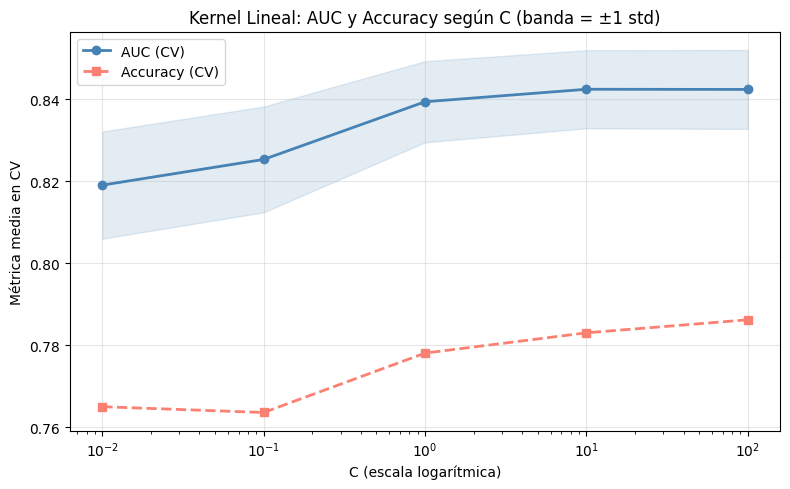

In [21]:
# Resultados de la Fase 1
results_df = pd.DataFrame(grid_fase1.cv_results_)
res_lin = results_df[results_df['param_kernel'] == 'linear'].copy()
res_rbf = results_df[results_df['param_kernel'] == 'rbf'].copy()

# --- Gráfico 1: Kernel Lineal — AUC y Accuracy vs C ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(res_lin['param_C'], res_lin['mean_test_AUC'],
        'o-', color='steelblue', lw=2, label='AUC (CV)')
ax.fill_between(res_lin['param_C'],
                res_lin['mean_test_AUC'] - res_lin['std_test_AUC'],
                res_lin['mean_test_AUC'] + res_lin['std_test_AUC'],
                alpha=0.15, color='steelblue')
ax.plot(res_lin['param_C'], res_lin['mean_test_Accuracy'],
        's--', color='salmon', lw=2, label='Accuracy (CV)')
ax.set_xscale('log')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Métrica media en CV')
ax.set_title('Kernel Lineal: AUC y Accuracy según C (banda = ±1 std)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

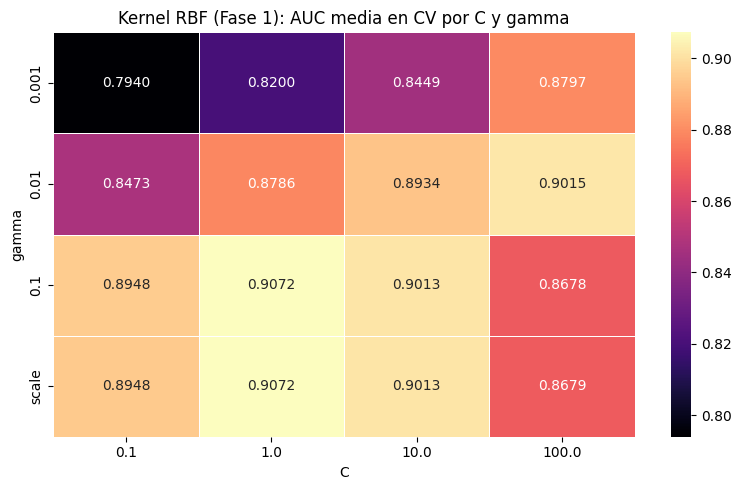

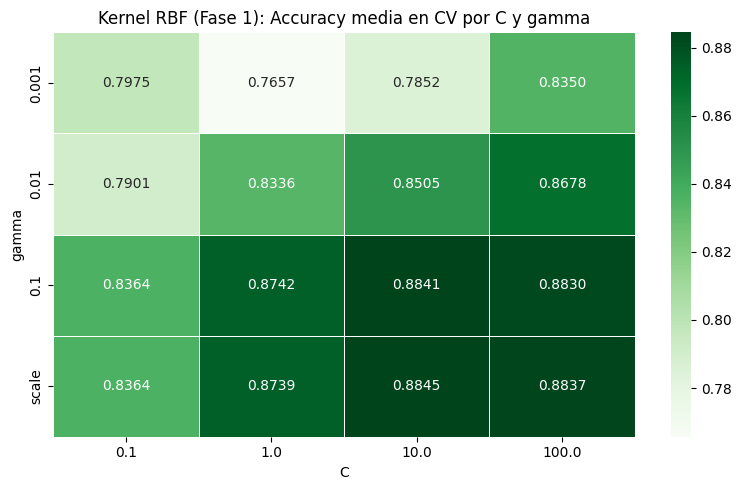

In [22]:
# --- Gráfico 2: Kernel RBF — Heatmap AUC (Fase 1) ---
res_rbf_plot = res_rbf.copy()
res_rbf_plot['param_gamma'] = res_rbf_plot['param_gamma'].astype(str)

pivot_auc = res_rbf_plot.pivot_table(index='param_gamma', columns='param_C',
                                      values='mean_test_AUC')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_auc, annot=True, fmt='.4f', cmap='magma', linewidths=0.5)
plt.title('Kernel RBF (Fase 1): AUC media en CV por C y gamma')
plt.xlabel('C'); plt.ylabel('gamma')
plt.tight_layout()
plt.show()

# --- Gráfico 3: Kernel RBF — Heatmap Accuracy (Fase 1) ---
pivot_acc = res_rbf_plot.pivot_table(index='param_gamma', columns='param_C',
                                      values='mean_test_Accuracy')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='Greens', linewidths=0.5)
plt.title('Kernel RBF (Fase 1): Accuracy media en CV por C y gamma')
plt.xlabel('C'); plt.ylabel('gamma')
plt.tight_layout()
plt.show()

### 2.2 Búsqueda de hiperparámetros — Fase 2 (refinamiento)

In [23]:
# FASE 2: Refinamiento en la zona óptima del RBF
best_C_f1 = grid_fase1.best_params_.get('C', 1)
best_g_f1 = grid_fase1.best_params_.get('gamma', 0.01)

# Construimos vecindad adaptativa
if isinstance(best_g_f1, str):  # 'scale'
    gamma_range = [0.001, 0.005, 0.01, 0.02, 0.05]
else:
    gamma_range = sorted(set([round(best_g_f1 * f, 6) for f in [0.2, 0.5, 1, 2, 5]]))

C_range = sorted(set([round(best_C_f1 * f, 6) for f in [0.25, 0.5, 1, 2, 5, 10]]))

print(f"Zona de refinamiento basada en Fase 1 (C={best_C_f1}, gamma={best_g_f1}):")
print(f"  C     = {C_range}")
print(f"  gamma = {gamma_range}")

param_grid_fase2 = {
    'kernel': ['rbf'],
    'C': C_range,
    'gamma': gamma_range
}

grid_fase2 = GridSearchCV(
    SVC(class_weight='balanced', probability=False, random_state=42),
    param_grid_fase2, cv=5,
    scoring={'AUC': 'roc_auc', 'Accuracy': 'accuracy'},
    refit='AUC', verbose=1, n_jobs=-1
)
grid_fase2.fit(X_train_svm, y_train)

print(f"\nMejores parámetros (Fase 2): {grid_fase2.best_params_}")
print(f"AUC validación (Fase 2):     {grid_fase2.best_score_:.4f}")

best_grid = grid_fase2

Zona de refinamiento basada en Fase 1 (C=1, gamma=0.1):
  C     = [0.25, 0.5, 1, 2, 5, 10]
  gamma = [0.02, 0.05, 0.1, 0.2, 0.5]
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores parámetros (Fase 2): {'C': 5, 'gamma': 0.05, 'kernel': 'rbf'}
AUC validación (Fase 2):     0.9076


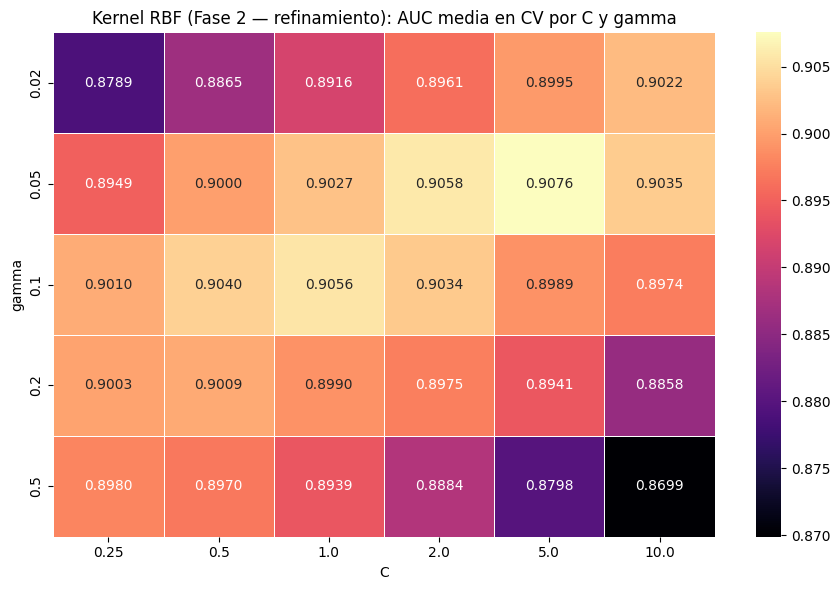

In [24]:
# --- Gráfico 4: Heatmap AUC del refinamiento (Fase 2) ---
res_f2 = pd.DataFrame(grid_fase2.cv_results_)
res_f2['param_gamma'] = res_f2['param_gamma'].astype(str)

pivot_f2 = res_f2.pivot_table(index='param_gamma', columns='param_C',
                               values='mean_test_AUC')
plt.figure(figsize=(9, 6))
sns.heatmap(pivot_f2, annot=True, fmt='.4f', cmap='magma', linewidths=0.5)
plt.title('Kernel RBF (Fase 2 — refinamiento): AUC media en CV por C y gamma')
plt.xlabel('C'); plt.ylabel('gamma')
plt.tight_layout()
plt.show()

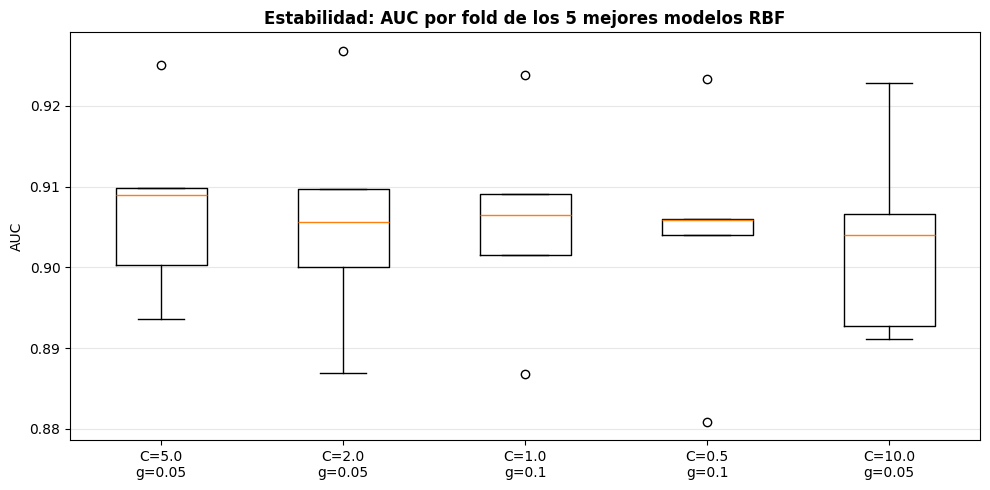

Top 5 configuraciones — media ± std de AUC en CV:
  C=   5.0, gamma=    0.05  →  AUC = 0.9076 ± 0.0106
  C=   2.0, gamma=    0.05  →  AUC = 0.9058 ± 0.0130
  C=   1.0, gamma=     0.1  →  AUC = 0.9056 ± 0.0120
  C=   0.5, gamma=     0.1  →  AUC = 0.9040 ± 0.0135
  C=  10.0, gamma=    0.05  →  AUC = 0.9035 ± 0.0114


In [25]:
# Análisis de estabilidad: boxplots de los folds para los 5 mejores modelos
res_best = pd.DataFrame(best_grid.cv_results_)
res_best = res_best.sort_values('mean_test_AUC', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 5))
fold_data = []
labels = []
for _, row in res_best.iterrows():
    folds = [row[f'split{k}_test_AUC'] for k in range(5)]
    fold_data.append(folds)
    labels.append(f"C={row['param_C']}\ng={row['param_gamma']}")

ax.boxplot(fold_data, labels=labels)
ax.set_ylabel('AUC')
ax.set_title('Estabilidad: AUC por fold de los 5 mejores modelos RBF', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Top 5 configuraciones — media ± std de AUC en CV:")
for _, row in res_best.iterrows():
    print(f"  C={row['param_C']:>6}, gamma={str(row['param_gamma']):>8}  →  "
          f"AUC = {row['mean_test_AUC']:.4f} ± {row['std_test_AUC']:.4f}")


### 2.3 Comparación de los dos mejores modelos (Lineal vs RBF)

In [26]:
# Mejor modelo RBF (del grid refinado, entrenado sobre variables reducidas)
best_svm = best_grid.best_estimator_

# Separar resultados del kernel lineal de la Fase 1
results_df = pd.DataFrame(grid_fase1.cv_results_)
res_lin = results_df[results_df['param_kernel'] == 'linear']

# Mejor modelo lineal
best_C_lin = res_lin.loc[res_lin['mean_test_AUC'].idxmax(), 'param_C']
best_svm_lin = SVC(kernel='linear', C=best_C_lin,
                   class_weight='balanced', probability=False, random_state=42)
best_svm_lin.fit(X_train_svm, y_train)

# Evaluación en TEST (conjunto reducido)
for nombre, modelo in [('SVM Lineal', best_svm_lin), ('SVM RBF', best_svm)]:
    yp  = modelo.predict(X_test_svm)
    ypr = modelo.decision_function(X_test_svm)
    print(f"\n{'='*40}")
    print(f"  {nombre}")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_test, yp):.4f}")
    print(f"  AUC      : {roc_auc_score(y_test, ypr):.4f}")
    print(classification_report(y_test, yp, target_names=['No Churn', 'Churn']))



  SVM Lineal
  Accuracy : 0.8121
  AUC      : 0.8683
              precision    recall  f1-score   support

    No Churn       0.95      0.81      0.87       567
       Churn       0.52      0.83      0.64       141

    accuracy                           0.81       708
   macro avg       0.73      0.82      0.76       708
weighted avg       0.86      0.81      0.83       708


  SVM RBF
  Accuracy : 0.8898
  AUC      : 0.9220
              precision    recall  f1-score   support

    No Churn       0.97      0.89      0.93       567
       Churn       0.67      0.89      0.76       141

    accuracy                           0.89       708
   macro avg       0.82      0.89      0.85       708
weighted avg       0.91      0.89      0.90       708



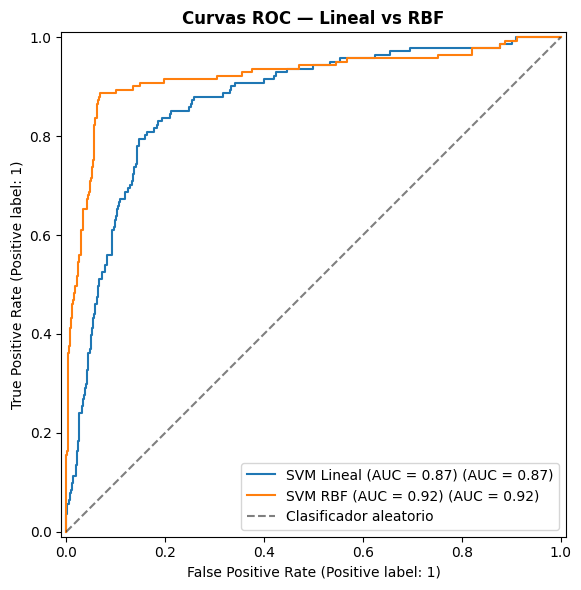

In [27]:
# Curvas ROC — Lineal vs RBF (evaluadas sobre el conjunto reducido)
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, modelo in [('SVM Lineal', best_svm_lin), ('SVM RBF', best_svm)]:
    ypr = modelo.decision_function(X_test_svm)
    auc_val = roc_auc_score(y_test, ypr)
    RocCurveDisplay.from_predictions(y_test, ypr, name=f"{nombre} (AUC = {auc_val:.2f})", ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador aleatorio')
ax.set_title('Curvas ROC — Lineal vs RBF', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


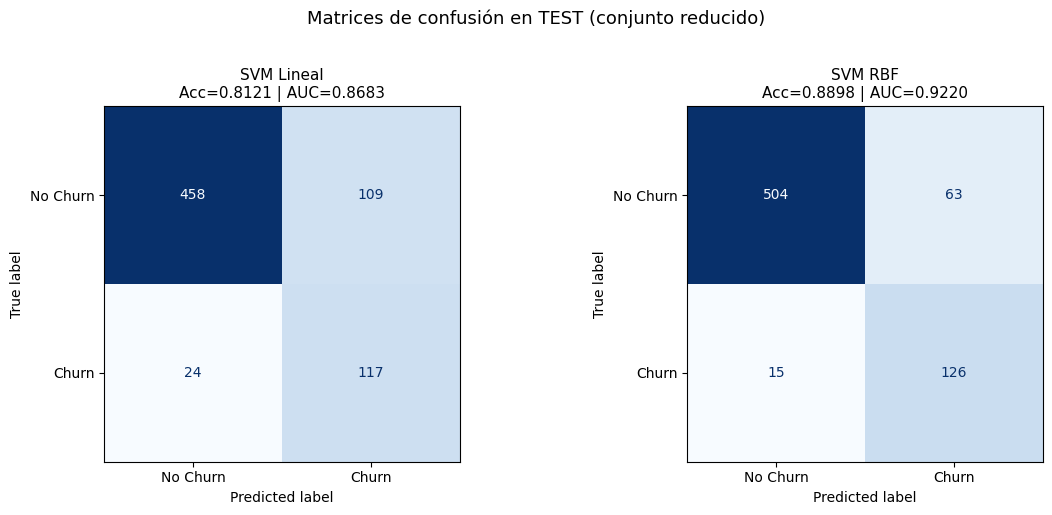

In [28]:
# Matrices de confusión — Lineal vs RBF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (nombre, modelo) in zip(axes, [('SVM Lineal', best_svm_lin), ('SVM RBF', best_svm)]):
    yp = modelo.predict(X_test_svm)
    cm = confusion_matrix(y_test, yp)
    acc = accuracy_score(y_test, yp)
    auc_val = roc_auc_score(y_test, modelo.decision_function(X_test_svm))
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{nombre}\nAcc={acc:.4f} | AUC={auc_val:.4f}', fontsize=11)
plt.suptitle('Matrices de confusión en TEST (conjunto reducido)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. ENSAMBLADO: Bagging y Stacking

### 3.1 Bagging sobre el mejor SVM

In [29]:
# Exploración de hiperparámetros del Bagging (sobre conjunto reducido, mismo que el SVM base)
print("Búsqueda de configuración del Bagging:\n")
resultados_bag = []
for n_est in [5, 10, 15, 25, 50]:
    for max_s in [0.6, 0.8, 1.0]:
        bag_temp = BaggingClassifier(
            estimator=best_svm,
            n_estimators=n_est,
            max_samples=max_s,
            random_state=42,
            n_jobs=-1
        )
        cv_auc = cross_val_score(bag_temp, X_train_svm, y_train,
                                 cv=3, scoring='roc_auc').mean()
        resultados_bag.append({'n_estimators': n_est, 'max_samples': max_s, 'AUC_CV': cv_auc})
        print(f"  n_est={n_est:3d}, max_samples={max_s:.1f}  →  AUC CV = {cv_auc:.4f}")

df_bag = pd.DataFrame(resultados_bag).sort_values('AUC_CV', ascending=False)
best_bag_row = df_bag.iloc[0]
print(f"\nMejor Bagging: n_est={int(best_bag_row['n_estimators'])}, "
      f"max_samples={best_bag_row['max_samples']:.1f}, AUC CV={best_bag_row['AUC_CV']:.4f}")

# Entrenar el Bagging final
bagging_model = BaggingClassifier(
    estimator=best_svm,
    n_estimators=int(best_bag_row['n_estimators']),
    max_samples=best_bag_row['max_samples'],
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_svm, y_train)

y_pred_bag = bagging_model.predict(X_test_svm)
y_prob_bag = bagging_model.predict_proba(X_test_svm)[:, 1]
acc_bag = accuracy_score(y_test, y_pred_bag)
auc_bag = roc_auc_score(y_test, y_prob_bag)

print(f"\nBagging final en TEST — Accuracy: {acc_bag:.4f}  |  AUC: {auc_bag:.4f}")
print(classification_report(y_test, y_pred_bag, target_names=['No Churn', 'Churn']))


Búsqueda de configuración del Bagging:

  n_est=  5, max_samples=0.6  →  AUC CV = 0.9065
  n_est=  5, max_samples=0.8  →  AUC CV = 0.9078
  n_est=  5, max_samples=1.0  →  AUC CV = 0.9073
  n_est= 10, max_samples=0.6  →  AUC CV = 0.9083
  n_est= 10, max_samples=0.8  →  AUC CV = 0.9088
  n_est= 10, max_samples=1.0  →  AUC CV = 0.9090
  n_est= 15, max_samples=0.6  →  AUC CV = 0.9083
  n_est= 15, max_samples=0.8  →  AUC CV = 0.9089
  n_est= 15, max_samples=1.0  →  AUC CV = 0.9086
  n_est= 25, max_samples=0.6  →  AUC CV = 0.9084
  n_est= 25, max_samples=0.8  →  AUC CV = 0.9088
  n_est= 25, max_samples=1.0  →  AUC CV = 0.9091
  n_est= 50, max_samples=0.6  →  AUC CV = 0.9092
  n_est= 50, max_samples=0.8  →  AUC CV = 0.9091
  n_est= 50, max_samples=1.0  →  AUC CV = 0.9092

Mejor Bagging: n_est=50, max_samples=1.0, AUC CV=0.9092

Bagging final en TEST — Accuracy: 0.9025  |  AUC: 0.9203
              precision    recall  f1-score   support

    No Churn       0.97      0.91      0.94       567
 

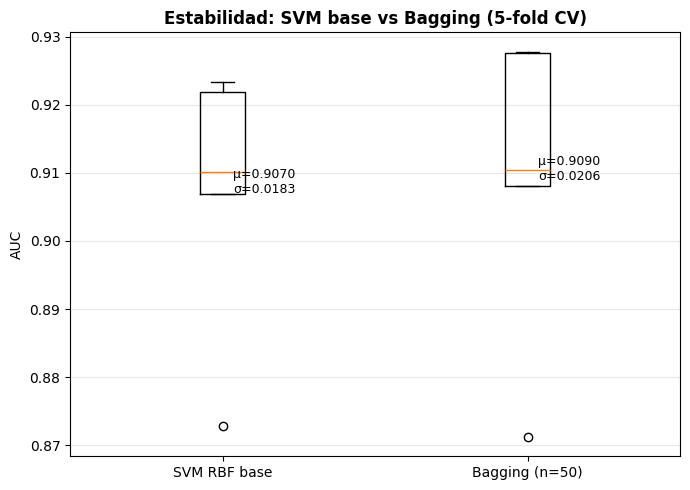

SVM base  — AUC: 0.9070 ± 0.0183
Bagging   — AUC: 0.9090 ± 0.0206
Diferencia:       +0.0020


In [30]:
# Boxplots de estabilidad: Bagging vs SVM base
# Compara la dispersión entre folds para ver si el bagging aporta reducción de varianza
skf_bag = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_svm_folds = cross_val_score(best_svm, X_train_svm, y_train,
                                cv=skf_bag, scoring='roc_auc')
cv_bag_folds = cross_val_score(bagging_model, X_train_svm, y_train,
                                cv=skf_bag, scoring='roc_auc')

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([cv_svm_folds, cv_bag_folds],
           labels=['SVM RBF base', f'Bagging (n={int(best_bag_row["n_estimators"])})'])
ax.set_ylabel('AUC')
ax.set_title('Estabilidad: SVM base vs Bagging (5-fold CV)', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

for i, datos in enumerate([cv_svm_folds, cv_bag_folds], 1):
    ax.annotate(f'μ={datos.mean():.4f}\nσ={datos.std():.4f}',
                xy=(i, datos.mean()), fontsize=9, ha='center',
                xytext=(30, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

print(f"SVM base  — AUC: {cv_svm_folds.mean():.4f} ± {cv_svm_folds.std():.4f}")
print(f"Bagging   — AUC: {cv_bag_folds.mean():.4f} ± {cv_bag_folds.std():.4f}")
print(f"Diferencia:       {cv_bag_folds.mean() - cv_svm_folds.mean():+.4f}")

### 3.2 Stacking

In [31]:
# Optimización del Random Forest (clasificador base del stacking)
# El RF usa el conjunto COMPLETO de variables: maneja bien la alta dimensionalidad
# y puede aprovechar las variables geográficas mediante sus particiones recursivas.
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_rf, cv=3, scoring='roc_auc', n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

print(f"Mejor Random Forest: {grid_rf.best_params_}")
print(f"AUC en CV:           {grid_rf.best_score_:.4f}")


Mejor Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
AUC en CV:           0.9173


In [32]:
# Top 5 configuraciones para análisis de estabilidad
res_rf = pd.DataFrame(grid_rf.cv_results_).sort_values('mean_test_score', ascending=False).head(5)
print("\nTop 5 configuraciones RF:")
for _, row in res_rf.iterrows():
    print(f"  depth={str(row['param_max_depth']):>4}, leaf={row['param_min_samples_leaf']}, "
          f"n_est={row['param_n_estimators']}  →  AUC = {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")


Top 5 configuraciones RF:
  depth=None, leaf=1, n_est=100  →  AUC = 0.9173 ± 0.0115
  depth=  10, leaf=1, n_est=100  →  AUC = 0.9171 ± 0.0143
  depth=None, leaf=1, n_est=200  →  AUC = 0.9170 ± 0.0102
  depth=  10, leaf=1, n_est=200  →  AUC = 0.9170 ± 0.0125
  depth=  10, leaf=5, n_est=100  →  AUC = 0.9170 ± 0.0122


In [33]:
# Evaluación del Random Forest en TEST (conjunto completo)
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest en TEST — Accuracy: {acc_rf:.4f}  |  AUC: {auc_rf:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


Random Forest en TEST — Accuracy: 0.9294  |  AUC: 0.9318
              precision    recall  f1-score   support

    No Churn       0.93      0.99      0.96       567
       Churn       0.94      0.69      0.80       141

    accuracy                           0.93       708
   macro avg       0.93      0.84      0.88       708
weighted avg       0.93      0.93      0.93       708



In [34]:
# Optimización mínima de la Regresión Logística base
print("Exploración de C para la Regresión Logística base:\n")
for c_lr in [0.01, 0.1, 1, 10, 25, 50, 100]:
    lr_temp = LogisticRegression(C=c_lr, class_weight='balanced',
                                 max_iter=1000, random_state=42)
    cv_lr = cross_val_score(lr_temp, X_train_scaled, y_train,
                            cv=3, scoring='roc_auc').mean()
    print(f"  C={c_lr}: AUC CV = {cv_lr:.4f}")

Exploración de C para la Regresión Logística base:

  C=0.01: AUC CV = 0.8101
  C=0.1: AUC CV = 0.8125
  C=1: AUC CV = 0.8241
  C=10: AUC CV = 0.8312
  C=25: AUC CV = 0.8315
  C=50: AUC CV = 0.8317
  C=100: AUC CV = 0.8317


In [35]:
# Selección del mejor C para la LR base
best_C_lr = 50
best_lr = LogisticRegression(C=best_C_lr, class_weight='balanced',
                              max_iter=1000, random_state=42)

# Clasificadores base del Stacking
# NOTA: El StackingClassifier pasa las mismas X a todos los estimadores base.
# Usamos el conjunto completo porque el RF (que domina el stacking) lo aprovecha.
# Se redefine el SVM base para el stacking con los mismos hiperparámetros óptimos.
svm_for_stack = SVC(**best_grid.best_params_,
                     class_weight='balanced', probability=False, random_state=42)

base_estimators = [
    ('svm', svm_for_stack),
    ('rf',  best_rf),
    ('lr',  best_lr)
]

# Optimización del meta-modelo
print("\nBúsqueda de regularización para el meta-modelo:\n")
for c_meta in [0.01, 0.1, 1, 10]:
    meta = LogisticRegression(C=c_meta, max_iter=500, random_state=42)
    stack_temp = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1
    )
    cv_auc = cross_val_score(stack_temp, X_train_scaled, y_train,
                             cv=3, scoring='roc_auc').mean()
    print(f"  C={c_meta}: AUC CV = {cv_auc:.4f}")



Búsqueda de regularización para el meta-modelo:

  C=0.01: AUC CV = 0.8863
  C=0.1: AUC CV = 0.9195
  C=1: AUC CV = 0.9174
  C=10: AUC CV = 0.9144


In [36]:
meta_model = LogisticRegression(C=0.1, max_iter=500, random_state=42)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)
stacking_model.fit(X_train_scaled, y_train)

y_pred_stack = stacking_model.predict(X_test_scaled)
y_prob_stack = stacking_model.predict_proba(X_test_scaled)[:, 1]
acc_stack = accuracy_score(y_test, y_pred_stack)
auc_stack = roc_auc_score(y_test, y_prob_stack)

print(f"Stacking — Accuracy: {acc_stack:.4f}")
print(f"Stacking — AUC:      {auc_stack:.4f}")
print(classification_report(y_test, y_pred_stack, target_names=['No Churn', 'Churn']))


Stacking — Accuracy: 0.9280
Stacking — AUC:      0.9253
              precision    recall  f1-score   support

    No Churn       0.93      0.98      0.96       567
       Churn       0.91      0.71      0.80       141

    accuracy                           0.93       708
   macro avg       0.92      0.85      0.88       708
weighted avg       0.93      0.93      0.92       708



In [37]:
# Coeficientes del meta-modelo: ¿cuánto pesa cada clasificador base?
meta = stacking_model.final_estimator_ 
nombres_base = [name for name, _ in stacking_model.estimators] 

print("Pesos del meta-modelo (Regresión Logística):\n") 
for name, coef in zip(nombres_base, meta.coef_[0]): 
    print(f" {name:>5s}: {coef:+.4f}") 

print(f" {'Inter':>5s}: {meta.intercept_[0]:+.4f}")


Pesos del meta-modelo (Regresión Logística):

   svm: +0.3830
    rf: +4.4010
    lr: +1.0018
 Inter: -2.8610


## 4. COMPARACIÓN GLOBAL DE MODELOS

### 4.1 Tabla resumen de resultados en test

In [38]:
# Tabla resumen — cada modelo evaluado con su conjunto de variables óptimo
# SVM y Bagging: conjunto reducido (10 vars) | RF y Stacking: conjunto completo (62 vars)
modelos_test = {
    'SVM Lineal (10v)':   (best_svm_lin.predict(X_test_svm),
                            best_svm_lin.decision_function(X_test_svm)),
    'SVM RBF (10v)':      (best_svm.predict(X_test_svm),
                            best_svm.decision_function(X_test_svm)),
    'Bagging+SVM (10v)':  (y_pred_bag, y_prob_bag),
    'Random Forest (62v)':(y_pred_rf, y_prob_rf),
    'Stacking (62v)':     (y_pred_stack, y_prob_stack),
}

rows = []
for nombre, (yp, yprob) in modelos_test.items():
    rows.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, yp),
        'AUC': roc_auc_score(y_test, yprob),
        'Precision_Churn': precision_score(y_test, yp),
        'Recall_Churn': recall_score(y_test, yp),
        'F1_Churn': f1_score(y_test, yp),
    })

comparison_df = pd.DataFrame(rows)
comparison_df.round(4)


,Modelo,Accuracy,AUC,Precision_Churn,Recall_Churn,F1_Churn
0,SVM Lineal (10v),0.8121,0.8683,0.5177,0.8298,0.6376
1,SVM RBF (10v),0.8898,0.9220,0.6667,0.8936,0.7636
2,Bagging+SVM (10v),0.9025,0.9203,0.7022,0.8865,0.7837
3,Random Forest (62v),0.9294,0.9318,0.9417,0.6879,0.7951
4,Stacking (62v),0.9280,0.9253,0.9091,0.7092,0.7968


### 4.2 Validación cruzada de robustez

In [39]:
# Validación cruzada de robustez
# SVM y Bagging se evalúan con el conjunto reducido; RF y Stacking con el completo
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv_config = {
    'SVM Lineal (10v)':      (best_svm_lin, X_train_svm),
    'SVM RBF (10v)':         (best_svm, X_train_svm),
    'Bagging + SVM (10v)':   (bagging_model, X_train_svm),
    'Random Forest (62v)':   (best_rf, X_train_scaled),
    'Stacking (62v)':        (stacking_model, X_train_scaled),
}

resultados_cv   = []
nombres_modelos = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, (modelo, X_data) in modelos_cv_config.items():
    cv_scores = cross_val_score(modelo, X_data, y_train,
                                cv=skf, scoring='roc_auc', n_jobs=-1)
    resultados_cv.append(cv_scores)
    nombres_modelos.append(nombre)
    print(f"{nombre}:")
    print(f"  AUC media: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
    print()


SVM Lineal (10v):
  AUC media: 0.8413 | Std: 0.0228

SVM RBF (10v):
  AUC media: 0.9070 | Std: 0.0183

Bagging + SVM (10v):
  AUC media: 0.9090 | Std: 0.0206

Random Forest (62v):
  AUC media: 0.9162 | Std: 0.0119

Stacking (62v):
  AUC media: 0.9198 | Std: 0.0178



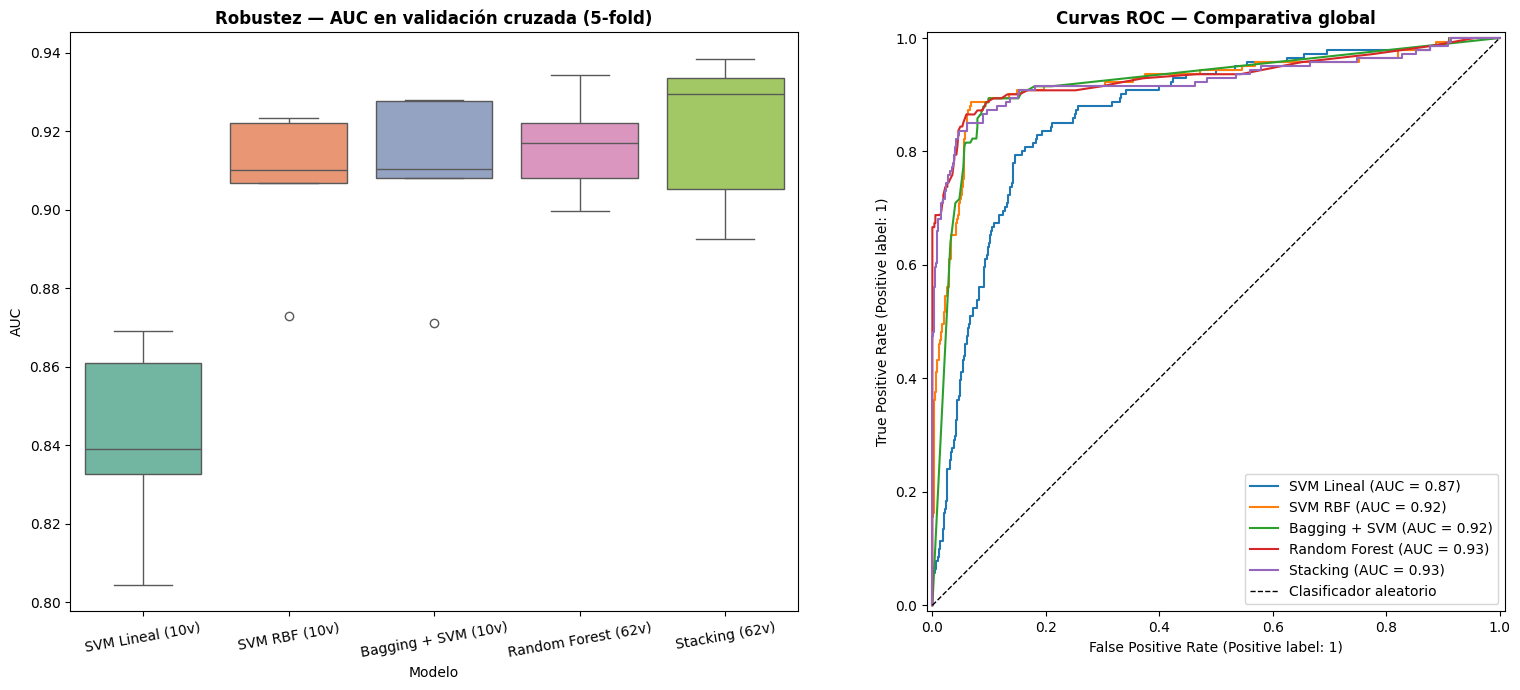

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Boxplots de robustez
sns.boxplot(data=resultados_cv, palette="Set2", ax=ax[0])
ax[0].set_xticks(range(len(nombres_modelos)))
ax[0].set_xticklabels(nombres_modelos, rotation=10)
ax[0].set_title("Robustez — AUC en validación cruzada (5-fold)", fontweight="bold")
ax[0].set_ylabel("AUC")
ax[0].set_xlabel("Modelo")

# Curvas ROC comparativas
modelos_roc = {
    'SVM Lineal':     (best_svm_lin,    X_test_svm),
    'SVM RBF':        (best_svm,        X_test_svm),
    'Bagging + SVM':  (bagging_model,   X_test_svm),
    'Random Forest':  (best_rf,         X_test_scaled),
    'Stacking':       (stacking_model,  X_test_scaled),
}
for nombre, (modelo, X_te) in modelos_roc.items():
    RocCurveDisplay.from_estimator(modelo, X_te, y_test,
                                    name=nombre, ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax[1].set_title("Curvas ROC — Comparativa global", fontweight="bold")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

### 4.3 Matriz de confusión de los modelos (Train + Test)

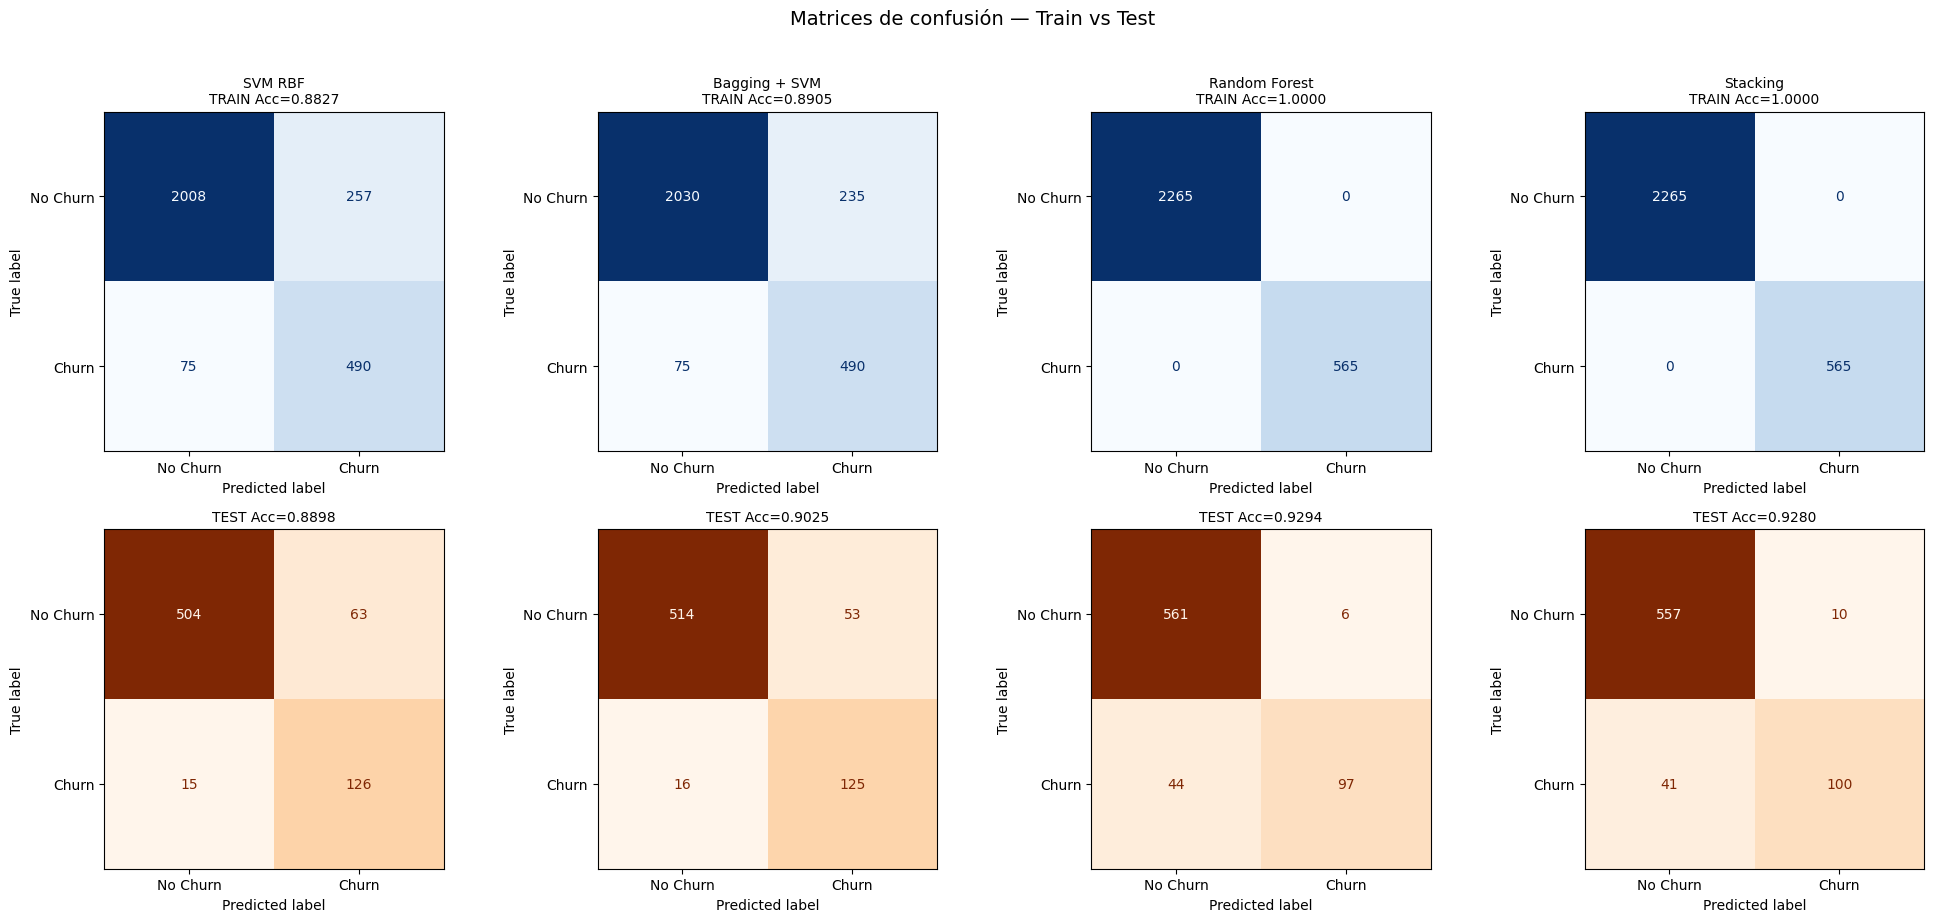

Modelo                Acc Train   Acc Test      Gap
--------------------------------------------------
SVM RBF                  0.8827     0.8898  -0.0071
Bagging + SVM            0.8905     0.9025  -0.0121
Random Forest            1.0000     0.9294   0.0706
Stacking                 1.0000     0.9280   0.0720


In [41]:
# Matrices de confusión — Train vs Test (cada modelo con su conjunto de variables)
modelos_cm = {
    'SVM RBF':        (best_svm, X_train_svm, X_test_svm),
    'Bagging + SVM':  (bagging_model, X_train_svm, X_test_svm),
    'Random Forest':  (best_rf, X_train_scaled, X_test_scaled),
    'Stacking':       (stacking_model, X_train_scaled, X_test_scaled),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for j, (nombre, (modelo, X_tr, X_te)) in enumerate(modelos_cm.items()):
    # TRAIN
    yp_tr = modelo.predict(X_tr)
    cm_tr = confusion_matrix(y_train, yp_tr)
    ConfusionMatrixDisplay(cm_tr, display_labels=['No Churn', 'Churn']).plot(
        ax=axes[0, j], cmap='Blues', colorbar=False)
    acc_tr = accuracy_score(y_train, yp_tr)
    axes[0, j].set_title(f'{nombre}\nTRAIN Acc={acc_tr:.4f}', fontsize=10)
    
    # TEST
    yp_te = modelo.predict(X_te)
    cm_te = confusion_matrix(y_test, yp_te)
    ConfusionMatrixDisplay(cm_te, display_labels=['No Churn', 'Churn']).plot(
        ax=axes[1, j], cmap='Oranges', colorbar=False)
    acc_te = accuracy_score(y_test, yp_te)
    axes[1, j].set_title(f'TEST Acc={acc_te:.4f}', fontsize=10)

plt.suptitle('Matrices de confusión — Train vs Test', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen del gap train-test
print(f"{'Modelo':<20} {'Acc Train':>10} {'Acc Test':>10} {'Gap':>8}")
print("-" * 50)
for nombre, (modelo, X_tr, X_te) in modelos_cm.items():
    acc_tr = accuracy_score(y_train, modelo.predict(X_tr))
    acc_te = accuracy_score(y_test, modelo.predict(X_te))
    print(f"{nombre:<20} {acc_tr:>10.4f} {acc_te:>10.4f} {acc_tr-acc_te:>8.4f}")


In [42]:
# Tabla de contingencia de TODOS los modelos en test
modelos_cm_tabla = {
    'SVM Lineal (10v)':    (best_svm_lin, X_test_svm),
    'SVM RBF (10v)':       (best_svm, X_test_svm),
    'Bagging+SVM (10v)':   (bagging_model, X_test_svm),
    'Random Forest (62v)': (best_rf, X_test_scaled),
    'Stacking (62v)':      (stacking_model, X_test_scaled),
}

for nombre, (modelo, X_te) in modelos_cm_tabla.items():
    cm = confusion_matrix(y_test, modelo.predict(X_te))
    tn, fp, fn, tp = cm.ravel()

    print("=" * 65)
    print(f"  {nombre}")
    print("=" * 65)
    print(f"{'':20s} {'Pred No Churn':>15s} {'Pred Churn':>15s} {'Total':>8s}")
    print("-" * 65)
    print(f"{'Real No Churn':20s} {tn:>8d} ({tn/(tn+fp)*100:4.1f}%) "
          f"{fp:>8d} ({fp/(tn+fp)*100:4.1f}%) {tn+fp:>8d}")
    print(f"{'Real Churn':20s} {fn:>8d} ({fn/(fn+tp)*100:4.1f}%) "
          f"{tp:>8d} ({tp/(fn+tp)*100:4.1f}%) {fn+tp:>8d}")
    print("-" * 65)
    print(f"{'Total':20s} {tn+fn:>8d}          {fp+tp:>8d}          {tn+fp+fn+tp:>8d}")
    print(f"  FN (churn no detectado): {fn} ({fn/(fn+tp)*100:.1f}% de los churn reales)")
    print(f"  FP (retención innecesaria): {fp} ({fp/(tn+fp)*100:.1f}% de los no-churn)")
    print()

  SVM Lineal (10v)
                       Pred No Churn      Pred Churn    Total
-----------------------------------------------------------------
Real No Churn             458 (80.8%)      109 (19.2%)      567
Real Churn                 24 (17.0%)      117 (83.0%)      141
-----------------------------------------------------------------
Total                     482               226               708
  FN (churn no detectado): 24 (17.0% de los churn reales)
  FP (retención innecesaria): 109 (19.2% de los no-churn)

  SVM RBF (10v)
                       Pred No Churn      Pred Churn    Total
-----------------------------------------------------------------
Real No Churn             504 (88.9%)       63 (11.1%)      567
Real Churn                 15 (10.6%)      126 (89.4%)      141
-----------------------------------------------------------------
Total                     519               189               708
  FN (churn no detectado): 15 (10.6% de los churn reales)
  FP (retenció

### 4.4 Robustez con distintas semillas de split

In [43]:
# Robustez cambiando la semilla del split — cada modelo con su conjunto de variables
seeds = [42, 123, 456, 789, 2024]
print("Robustez con distintas semillas de split:\n")
aucs_svm = []
aucs_rf = []
aucs_stack = []

for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    # Conjunto reducido para SVM
    sc_r = StandardScaler()
    X_tr_svm = sc_r.fit_transform(X_tr[cols_reducido])
    X_te_svm = sc_r.transform(X_te[cols_reducido])
    
    # Conjunto completo para RF y Stacking
    sc_f = StandardScaler()
    X_tr_full = sc_f.fit_transform(X_tr)
    X_te_full = sc_f.transform(X_te)

    # SVM RBF (conjunto reducido)
    svm_rob = SVC(**best_grid.best_params_,
                  class_weight='balanced', probability=False, random_state=42)
    svm_rob.fit(X_tr_svm, y_tr)
    auc_svm = roc_auc_score(y_te, svm_rob.decision_function(X_te_svm))
    aucs_svm.append(auc_svm)

    # Random Forest (conjunto completo)
    rf_rob = RandomForestClassifier(**grid_rf.best_params_,
                class_weight='balanced', random_state=42)
    rf_rob.fit(X_tr_full, y_tr)
    auc_rf_r = roc_auc_score(y_te, rf_rob.predict_proba(X_te_full)[:, 1])
    aucs_rf.append(auc_rf_r)

    # Stacking (conjunto completo)
    stack_rob = StackingClassifier(
        estimators=[
            ('svm', SVC(**best_grid.best_params_,
                        class_weight='balanced', probability=False, random_state=42)),
            ('rf',  RandomForestClassifier(**grid_rf.best_params_,
                        class_weight='balanced', random_state=42)),
            ('lr',  LogisticRegression(C=best_C_lr, class_weight='balanced',
                                       max_iter=1000, random_state=42))
        ],
        final_estimator=LogisticRegression(C=0.1, max_iter=500, random_state=42),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1
    )
    stack_rob.fit(X_tr_full, y_tr)
    auc_stk = roc_auc_score(y_te, stack_rob.predict_proba(X_te_full)[:, 1])
    aucs_stack.append(auc_stk)

    print(f"  Seed {seed:4d}:  SVM={auc_svm:.4f}  |  RF={auc_rf_r:.4f}  |  Stacking={auc_stk:.4f}")

print(f"\nSVM RBF (10v)  — AUC medio: {np.mean(aucs_svm):.4f} ± {np.std(aucs_svm):.4f}  "
      f"Rango: [{min(aucs_svm):.4f}, {max(aucs_svm):.4f}]")
print(f"RF (62v)       — AUC medio: {np.mean(aucs_rf):.4f} ± {np.std(aucs_rf):.4f}  "
      f"Rango: [{min(aucs_rf):.4f}, {max(aucs_rf):.4f}]")
print(f"Stacking (62v) — AUC medio: {np.mean(aucs_stack):.4f} ± {np.std(aucs_stack):.4f}  "
      f"Rango: [{min(aucs_stack):.4f}, {max(aucs_stack):.4f}]")


Robustez con distintas semillas de split:

  Seed   42:  SVM=0.9220  |  RF=0.9318  |  Stacking=0.9253
  Seed  123:  SVM=0.9238  |  RF=0.9235  |  Stacking=0.9292
  Seed  456:  SVM=0.8912  |  RF=0.8928  |  Stacking=0.9016
  Seed  789:  SVM=0.9008  |  RF=0.9116  |  Stacking=0.9174
  Seed 2024:  SVM=0.9007  |  RF=0.9162  |  Stacking=0.9175

SVM RBF (10v)  — AUC medio: 0.9077 ± 0.0129  Rango: [0.8912, 0.9238]
RF (62v)       — AUC medio: 0.9152 ± 0.0131  Rango: [0.8928, 0.9318]
Stacking (62v) — AUC medio: 0.9182 ± 0.0095  Rango: [0.9016, 0.9292]
